In [2]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
# every time you run a cell, all imported modules are reloaded auomatically
%load_ext autoreload
%autoreload 2 

In [3]:
# Real Data management
import os
import scipy.io

# Imports for math and graphics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy
from kneed import KneeLocator

# Our package
import neuro_lib as nlib
from neuro_lib.plotting import TE_heatMat
from neuro_lib.transfer_entropy import transfer_entropy_matrix
from neuro_lib.diagnostics import permutation_test_TE

# MUTUAL INFORMATION ESTIMATION ON REAL BRAIN DATA TIME SERIES

## Data description

The data are brain signals recorded via resting-state functional MRI (fMRI).  
Each of the two matrices contains **1200 time points** for **119 brain regions**.  
The two matrices correspond to two recording sessions of the same subject  
(ideally, they could be used to verify the consistency of the estimates).

## Tasks

1. If computationally feasible, calculate a **transfer entropy matrix** of size 119 × 119,  
   where the element (i,j) represents the **transfer entropy** from the i-th signal to the j-th signal.
2. Compare the matrices obtained using different methods.
3. Evaluate the **consistency** of the results across the two sessions.

**Note:** If the computation is too heavy, you can restrict yourself to a **subset of the time series**  
(for example, the first 10 regions or even just the first 2).

# Load the data

In [4]:
# Define the data directory
data_dir = "Data"

# Define the file names
file1 = "100307.REST1.LR.SchaeferS.ptseries.mat"
file2 = "100307.REST2.LR.SchaeferS.ptseries.mat"

# Construct full paths
path1 = os.path.join(data_dir, file1)
path2 = os.path.join(data_dir, file2)

# Load the .mat files
data1 = scipy.io.loadmat(path1)
data2 = scipy.io.loadmat(path2)

# Check the keys in the loaded data
print("Keys in REST1 data:", data1.keys())
print("Keys in REST2 data:", data2.keys())

# Get time series
data1_mat = data1['tseries']  # shape (119, 1200)
data2_mat = data2['tseries']  # shape (119, 1200)

Keys in REST1 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])
Keys in REST2 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


# **TE METHODS IMPLEMENTATIONS**

Transfer Entropy from a source signal $S$ to a target signal $X$ is defined as:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

where $\ell$ is the chosen lag.

# Binning

The binning approach estimates entropies by discretizing continuous variables:

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Discretization:**
   Each variable is divided into $n_{\text{bins}}$ intervals, and empirical counts are computed.

3. **Conditional entropy estimation:**
   - $H(X_t \mid X_{t-1})$ is computed using a 2D histogram
   - $H(X_t \mid X_{t-1}, S_{t-\ell})$ is computed using a 3D histogram

4. **Transfer Entropy:**
$$
TE = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

#### Notes

- A Miller bias correction can optionally be applied.
- The method is fully non-parametric.
- It can capture nonlinear dependencies, but is sensitive to:
  - number of bins
  - finite sample effects (especially in higher dimensions)

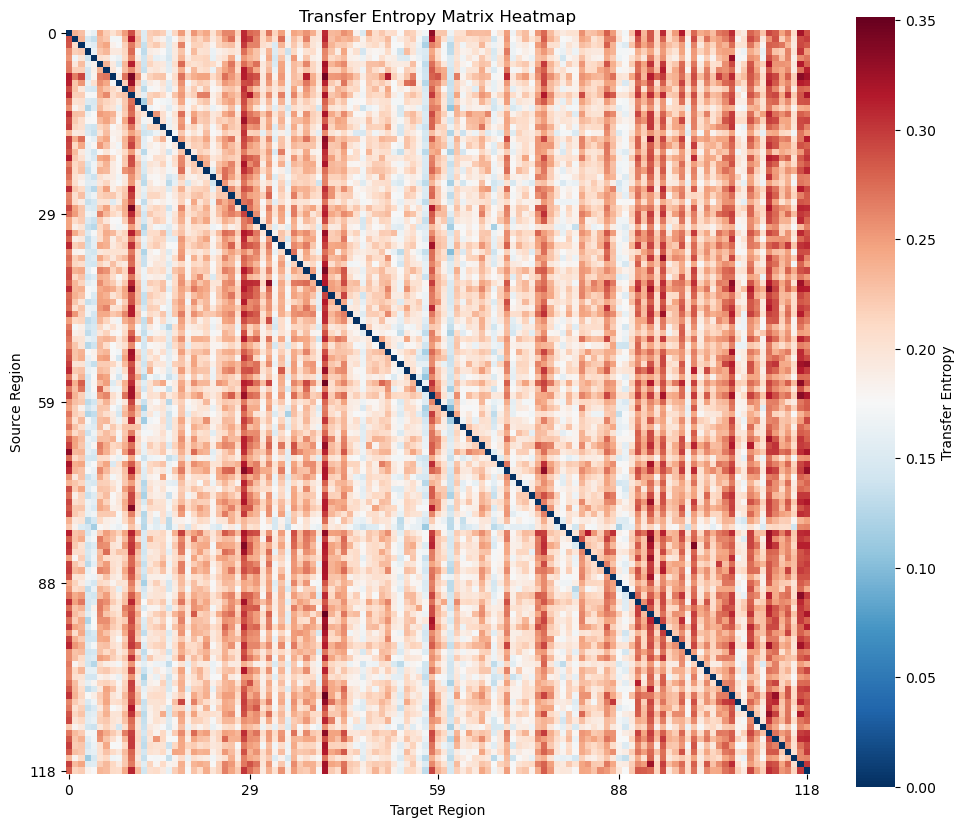

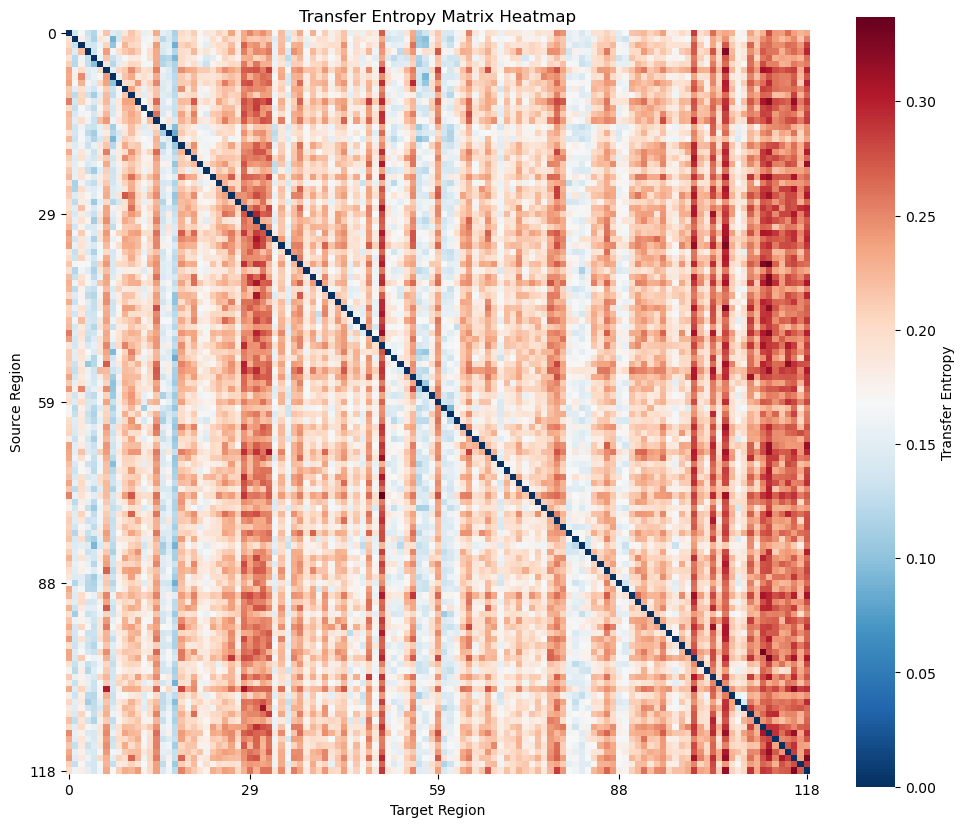

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [5]:
nbins = int(1200**(1/3))
TE_real_bin_1 = nlib.transfer_entropy_matrix(data1_mat, n_bins=nbins, lag=1)
TE_real_bin_2 = nlib.transfer_entropy_matrix(data2_mat, n_bins=nbins, lag=1)
TE_heatMat(TE_real_bin_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_bin_2, cmap="RdBu_r", figsize=(12,10))

# Joint Gaussian assumption

Under the assumption that variables are jointly Gaussian, Transfer Entropy can be computed analytically.

Starting from:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

For Gaussian variables, conditional entropy depends only on conditional variance:
$$
H(X \mid Y) = \frac{1}{2} \log(2\pi e \, \mathrm{Var}(X \mid Y))
$$

Thus, Transfer Entropy becomes:
$$
TE = \frac{1}{2} \log \left( \frac{\mathrm{Var}(X_t \mid X_{t-1})}{\mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell})} \right)
$$

So the implementation proceeds as follows: 

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Conditional variances are computed using covariance matrices:**
$$
\mathrm{Var}(X \mid Y) =
\mathrm{Var}(X) - \mathrm{Cov}(X,Y)\,\mathrm{Var}(Y)^{-1}\,\mathrm{Cov}(Y,X)
$$

3. **Transfer Entropy is obtained as:**
$$
TE = \frac{1}{2} \log \left( \frac{\mathrm{Var}_1}{\mathrm{Var}_2} \right)
$$

where:
- $\mathrm{Var}_1 = \mathrm{Var}(X_t \mid X_{t-1})$
- $\mathrm{Var}_2 = \mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell})$

#### Notes

- Equivalent to linear Granger causality under Gaussian assumptions.
- Computationally efficient and robust for high-dimensional data.
- Only captures **linear dependencies**.


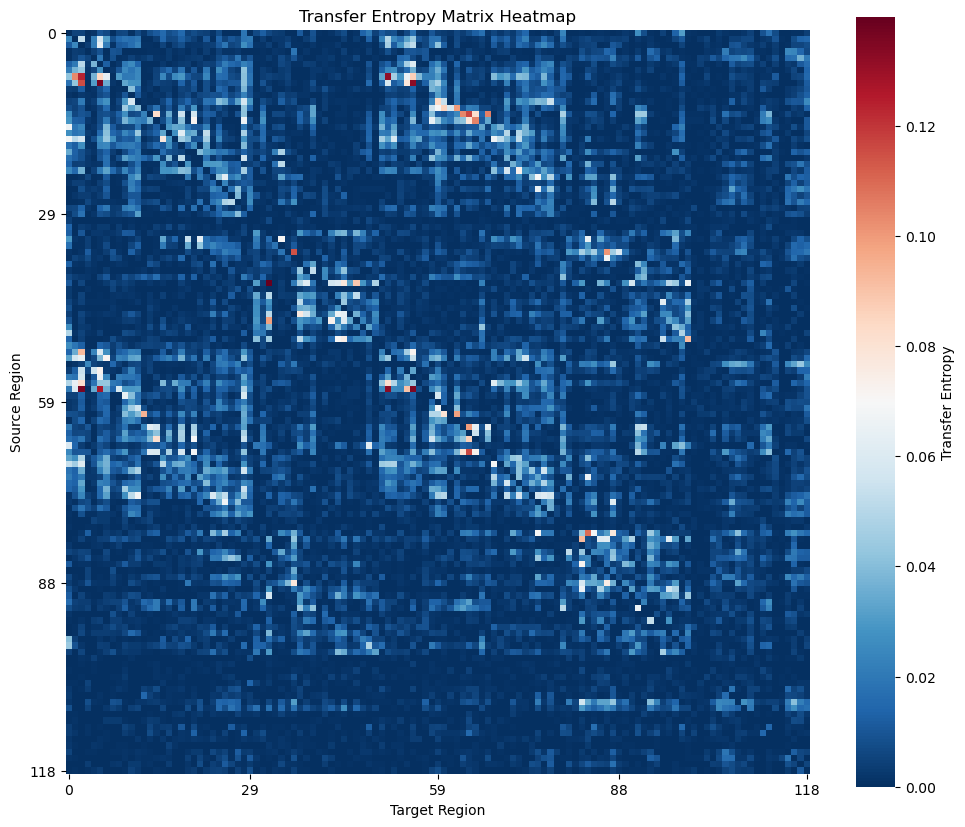

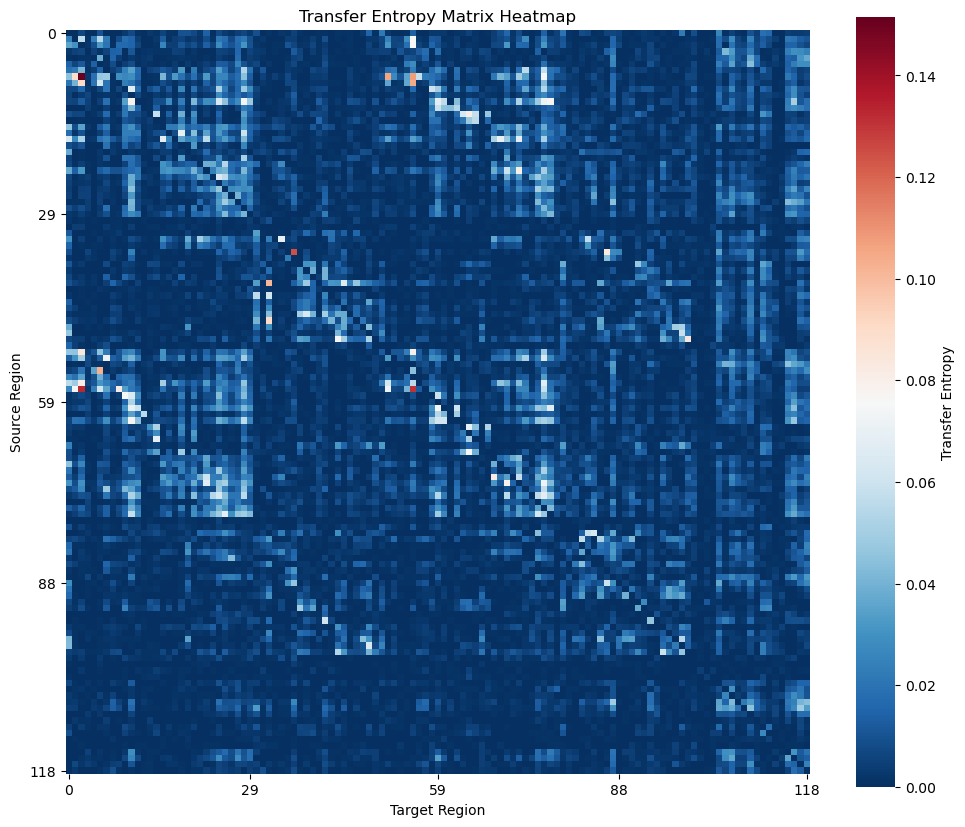

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [6]:
TE_real_gauss_1 = nlib.transfer_entropy_matrix(data1_mat, method = "gaussian", lag=1)
TE_real_gauss_2 = nlib.transfer_entropy_matrix(data2_mat, method = "gaussian", lag=1)
TE_heatMat(TE_real_gauss_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_gauss_2, cmap="RdBu_r",  figsize=(12,10))

# KDE method

Transfer Entropy can be expressed in terms of conditional entropy:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

This is the **direct entropy decomposition**, equivalent to the conditional MI formulation
$I(X_t ; S_{t-\ell} \mid X_{t-1})$, but more natural for KDE-based estimation.

Using the chain rule of entropy, each conditional entropy expands as:
$$
H(X_t \mid X_{t-1}) = H(X_t, X_{t-1}) - H(X_{t-1})
$$
$$
H(X_t \mid X_{t-1}, S_{t-\ell}) = H(X_t, X_{t-1}, S_{t-\ell}) - H(X_{t-1}, S_{t-\ell})
$$

so the full expression becomes:
$$
TE = \underbrace{H(X_t, X_{t-1}, S_{t-\ell})}_{\text{3D}} 
   - \underbrace{H(X_{t-1}, S_{t-\ell})}_{\text{2D}} 
   - \underbrace{H(X_t, X_{t-1})}_{\text{2D}} 
   + \underbrace{H(X_{t-1})}_{\text{1D}}
$$

which in plug-in KDE form is:
$$
TE = -\mathbb{E}\bigl[\log_2 p(X_t, X_{t-1}, S_{t-\ell})\bigr]
   + \mathbb{E}\bigl[\log_2 p(X_{t-1}, S_{t-\ell})\bigr]
   + \mathbb{E}\bigl[\log_2 p(X_t, X_{t-1})\bigr]
   - \mathbb{E}\bigl[\log_2 p(X_{t-1})\bigr]
$$

#### Implementation

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Four KDE density estimates are computed** (plug-in: KDE fitted and evaluated on the same samples):
   - $p(X_t, X_{t-1}, S_{t-\ell})$ — 3D joint
   - $p(X_{t-1}, S_{t-\ell})$ — 2D joint
   - $p(X_t, X_{t-1})$ — 2D joint
   - $p(X_{t-1})$ — 1D marginal

3. **Transfer Entropy** is computed as the sample average:
$$
TE = \mathbb{E}\bigl[\log_2 p(X_t, X_{t-1}, S_{t-\ell}) - \log_2 p(X_{t-1}, S_{t-\ell})
   - \log_2 p(X_t, X_{t-1}) + \log_2 p(X_{t-1})\bigr]
$$

#### Notes

- Fully non-parametric: captures nonlinear dependencies without distributional assumptions.
- More flexible than Gaussian TE, but:
  - computationally expensive
  - sensitive to bandwidth selection (parameter $\alpha$)
  - the 3D KDE fit degrades with fewer than ~500 samples

In [ ]:
# NOTICE: on full data is VERY SLOW - KDE scales very badly with both sample 
#         size and dimensionality --> we reduce analysis to first 10 brain regions
TE_real_kde_1 = nlib.transfer_entropy_matrix(data1_mat[:10,:], method="kde", alpha=1.0)
TE_real_kde_2 = nlib.transfer_entropy_matrix(data2_mat[:10,:], method="kde", alpha=1.0)

TE_heatMat(TE_real_kde_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_kde_2, cmap="RdBu_r", figsize=(12,10))

# Gaussian Copula Method

The Gaussian Copula approach provides a semi-parametric method to estimate Transfer Entropy by combining:
- non-parametric marginal distributions
- Gaussian dependence modeling in a transformed space

The starting point is:
$$
TE_{S \to X} = I(X_t ; S_{t-\ell} \mid X_{t-1})
$$

Using the identity:
$$
TE = I(X_t ; S_{t-\ell}, X_{t-1}) - I(X_t ; X_{t-1})
$$

#### Implementation

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (source)
   - $X_{t-1}$ (target past)
   - $X_t$ (target)

2. **Gaussian Copula transformation:**
   - Each variable is mapped to its empirical CDF:
     $U_X = F_X(X)$
   - Then transformed to Gaussian space:
     $Z_X = \Phi^{-1}(U_X)$

   This step preserves rank structure while enforcing Gaussian marginals.

3. **Gaussian MI in transformed space:**
   - $I(X_t ; X_{t-1})$
   - $I(X_t ; X_{t-1}, S_{t-\ell})$

   are computed assuming multivariate Gaussian structure via covariance matrices.

4. **Transfer Entropy:**
$$
TE = I(X_t ; S_{t-\ell}, X_{t-1}) - I(X_t ; X_{t-1})
$$

#### Notes

- This method is **nonlinear in marginals but Gaussian in dependence structure**.
- It is more flexible than standard Gaussian TE, since:
  - marginal distributions are fully non-parametric
- Compared to KDE:
  - more stable in moderate sample sizes
  - less flexible in capturing arbitrary nonlinear dependencies
- Compared to binning:
  - avoids discretization artifacts
  - but assumes Gaussian copula structure after transformation
- Requires multivariate Gaussian MI (via covariance determinants): for jointly Gaussian variables the mutual information between a scalar variable $X$ and a vector $Y \in \mathbb{R}^d$ is given by:
$$
I(X;Y) = \frac{1}{2}\log_2 \left( \frac{\det \Sigma_X \, \det \Sigma_Y}{\det \Sigma_{XY}} \right)
$$

where:
- $\Sigma_X \in \mathbb{R}^{1 \times 1}$ is the variance of $X$,
- $\Sigma_Y \in \mathbb{R}^{d \times d}$ is the covariance matrix of $Y = (X_{t-1}, S_{t-\ell})$,
- $\Sigma_{XY} \in \mathbb{R}^{(d+1)\times(d+1)}$ is the full joint covariance matrix of $(X, Y)$.

This replaces the previous pairwise-only formula:
$$
I(X;Y) = -\frac{1}{2}\log_2(1 - \rho^2)
$$
which is valid only in the special case where both $X$ and $Y$ are scalar random variables.

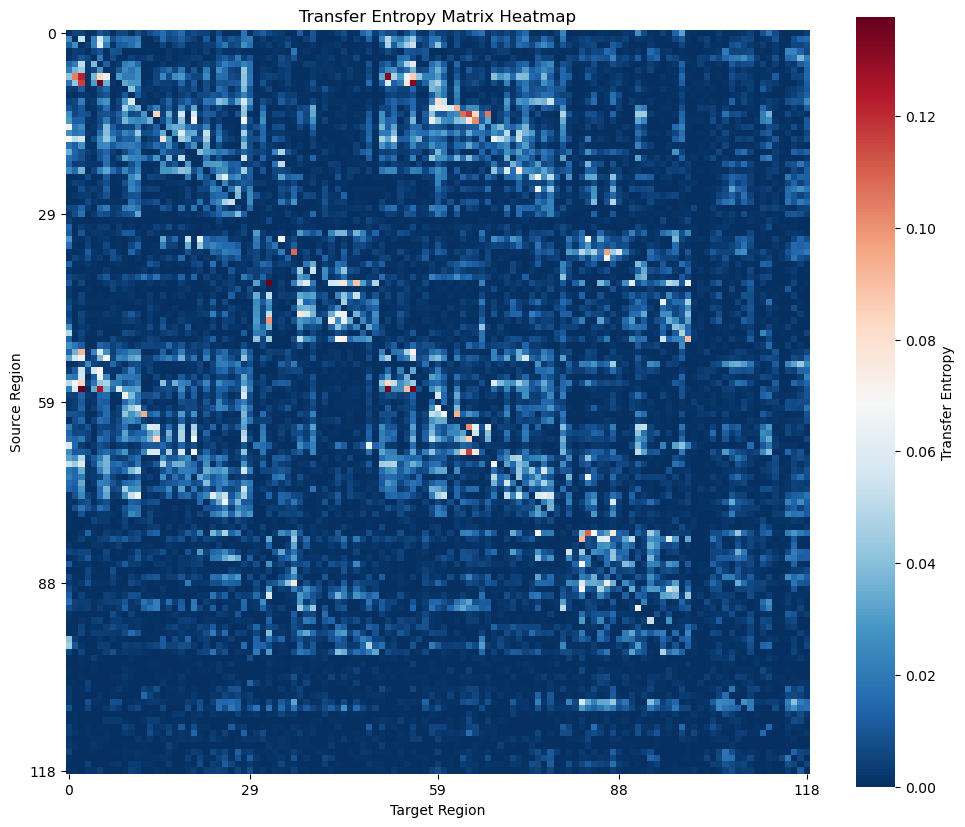

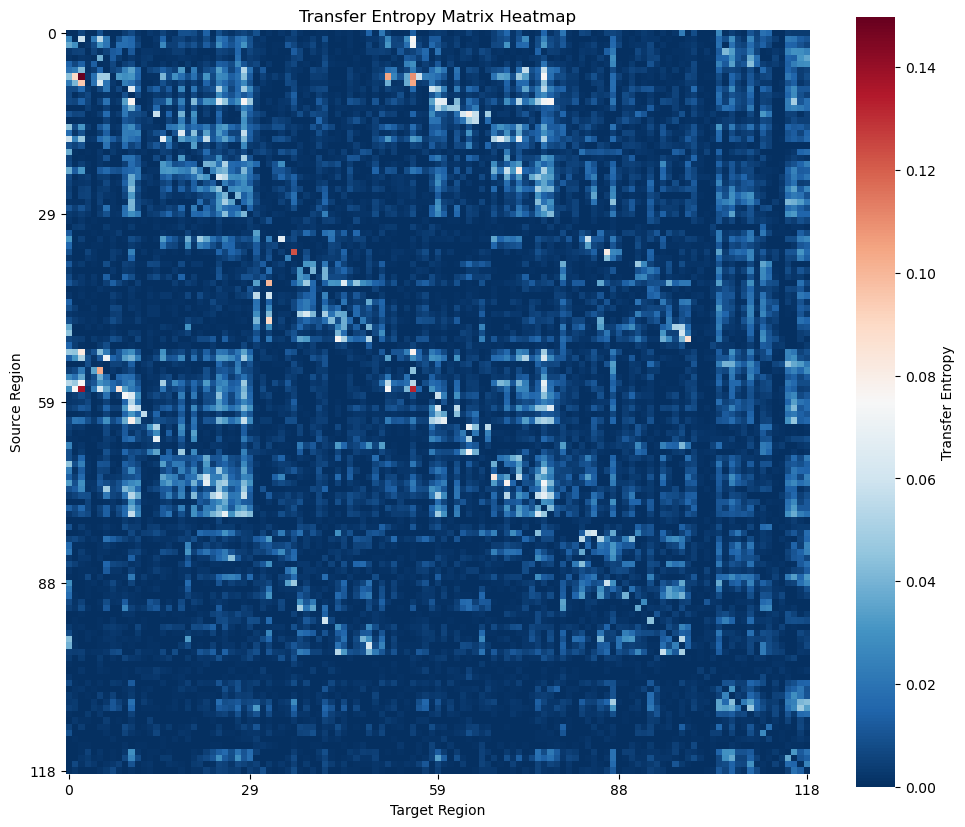

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [ ]:
TE_real_copula_1 = nlib.transfer_entropy_matrix(data1_mat, method="copula")
TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat, method="copula")

TE_heatMat(TE_real_copula_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_copula_2, cmap="RdBu_r", figsize=(12,10))

# **ANALYSIS** - **NULL DISTRIBUTION & HYPOTHESIS TESTING**

We want to distinguish real TE from the apparent one coming from finite-sample bias.

Any TE estimator applied to finite data will produce small non-zero values even between
completely independent signals — this is **finite-sample bias**, not a real connection.

To assess whether a measured TE value is genuine, we use a **permutation test**:

1. **Build a null distribution**: shuffle the source signal many times (destroying any
   real temporal coupling), and recompute TE each time. This gives us a distribution
   of TE values expected purely by chance.

2. **Compute a p-value** for each pair (i,j): the fraction of null TE values that are
   greater than or equal to the real TE. A small p-value means the real TE is
   unlikely to have arisen by chance.

3. **Apply FDR correction** (Benjamini-Hochberg): since we test ~14,000 pairs
   simultaneously, running each test at 5% would give ~700 false positives even with
   no real connections. FDR correction ensures that among *all* pairs we call
   significant, at most 5% are expected to be false discoveries.

We start from **dataset 1**.

In [ ]:
# PARAMETERS — shared across all methods and sessions

# General parameters for TE computation
lag = 4
kde_regions = 10
nbins = int(1200**(1/3))

# Parameters for permutation testing
n_perms = 10
alpha   = 0.05   # significance threshold (5% → 95% confidence)

In [ ]:
# Session 1 — Gaussian
# TE_real_gauss_1 was already computed above, we pass it directly
print("Session 1 — Gaussian")
sig_gauss_1, p_gauss_1, null95_gauss_1 = permutation_test_TE(
    data1_mat, TE_real_gauss_1, method="gaussian",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

# Session 1 — Copula
print("\nSession 1 — Copula")
sig_copula_1, p_copula_1, null95_copula_1 = permutation_test_TE(
    data1_mat, TE_real_copula_1, method="copula",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

# Session 1 — Binning
print("\nSession 1 — Binning")
sig_bin_1, p_bin_1, null95_bin_1 = permutation_test_TE(
    data1_mat, TE_real_bin_1, method="binning",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag, n_bins=nbins)

# Session 1 — KDE (only first kde_regions regions)
print("\nSession 1 — KDE")
sig_kde_1, p_kde_1, null95_kde_1 = permutation_test_TE(
    data1_mat[:kde_regions, :], TE_real_kde_1, method="kde",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

Session 1 — Gaussian
  [gaussian] shuffle 0/10...
  → 7019 significant connections (FDR-corrected, α=0.05)

Session 1 — Copula
  [copula] shuffle 0/10...
  → 6977 significant connections (FDR-corrected, α=0.05)

Session 1 — Binning
  [binning] shuffle 0/10...
  → 348 significant connections (FDR-corrected, α=0.05)

Session 1 — KDE
  [kde] shuffle 0/10...
  → 50 significant connections (FDR-corrected, α=0.05)


In [ ]:
# Recompute real TE for session 2 
# (if you already have TE_real_gauss_2 etc. from earlier cells, skip these lines)
TE_real_gauss_2  = nlib.transfer_entropy_matrix(data2_mat, method="gaussian", lag=lag)
TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat, method="copula",   lag=lag)
TE_real_bin_2    = nlib.transfer_entropy_matrix(data2_mat, method="binning",  lag=lag, n_bins=nbins)
TE_real_kde_2    = nlib.transfer_entropy_matrix(data2_mat[:kde_regions, :], method="kde", lag=lag)

print("Session 2 — Gaussian")
sig_gauss_2, p_gauss_2, null95_gauss_2 = permutation_test_TE(
    data2_mat, TE_real_gauss_2, method="gaussian",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

print("\nSession 2 — Copula")
sig_copula_2, p_copula_2, null95_copula_2 = permutation_test_TE(
    data2_mat, TE_real_copula_2, method="copula",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

print("\nSession 2 — Binning")
sig_bin_2, p_bin_2, null95_bin_2 = permutation_test_TE(
    data2_mat, TE_real_bin_2, method="binning",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag, n_bins=nbins)

print("\nSession 2 — KDE")
sig_kde_2, p_kde_2, null95_kde_2 = permutation_test_TE(
    data2_mat[:kde_regions, :], TE_real_kde_2, method="kde",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

Session 2 — Gaussian
  [gaussian] shuffle 0/10...
  → 4666 significant connections (FDR-corrected, α=0.05)

Session 2 — Copula
  [copula] shuffle 0/10...
  → 4643 significant connections (FDR-corrected, α=0.05)

Session 2 — Binning
  [binning] shuffle 0/10...
  → 287 significant connections (FDR-corrected, α=0.05)

Session 2 — KDE
  [kde] shuffle 0/10...
  → 15 significant connections (FDR-corrected, α=0.05)


Significant connections (FDR α=0.05, 10 permutations):
  Gaussian  — S1: 7019,  S2: 4666
  Copula    — S1: 6977,  S2: 4643
  Binning   — S1:  348,  S2:  287
  KDE       — S1:   50,  S2:   15
  Robust (Gauss + Copula, both sessions): 2568


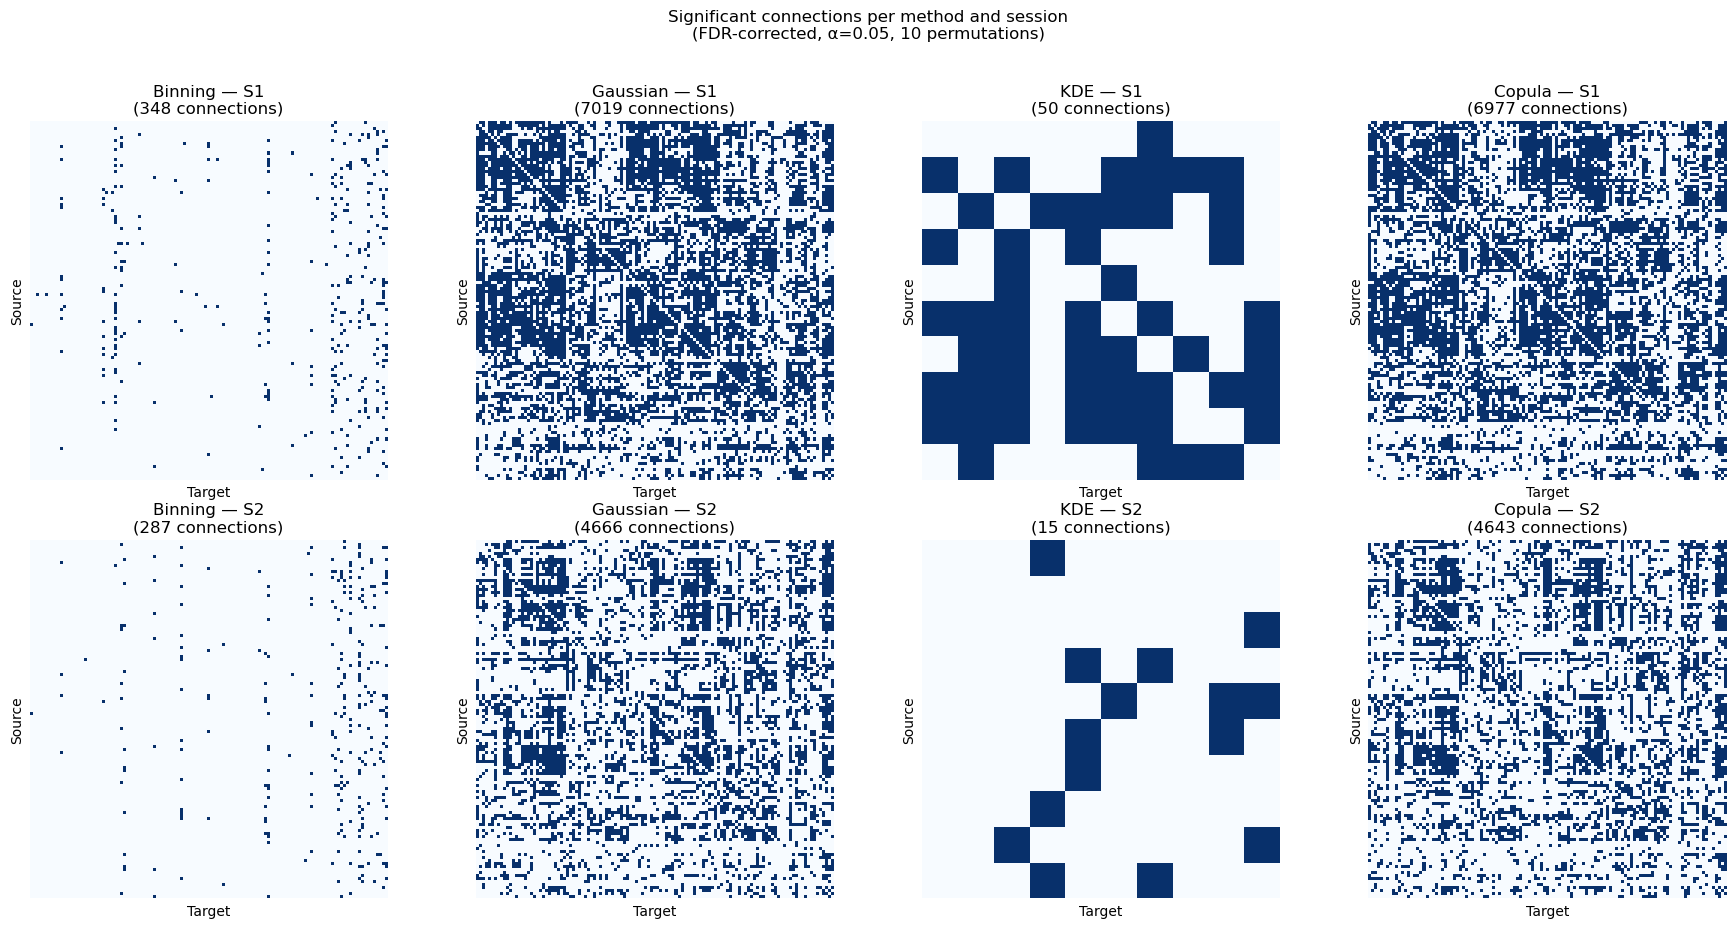

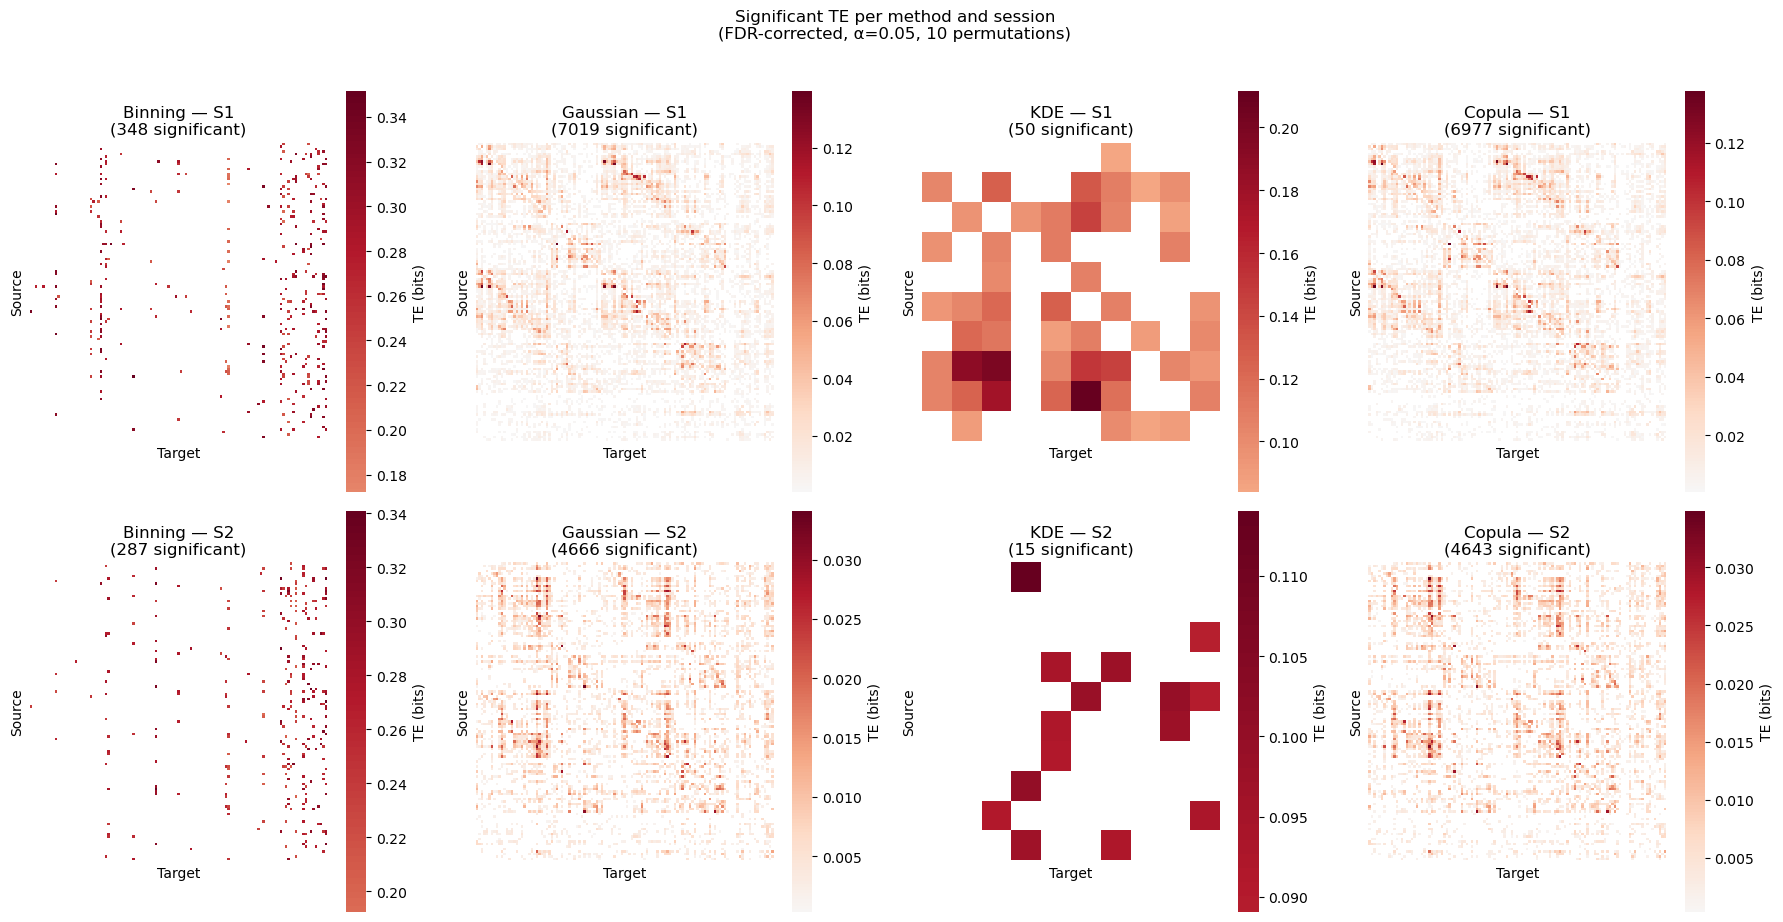

Robust connections surviving both sessions (FDR α=0.05, 10 permutations):
Method           S1     S2   Both
--------------------------------
Binning         348    287     21
Gaussian       7019   4666   3190
KDE              50     15      7
Copula         6977   4643   3167


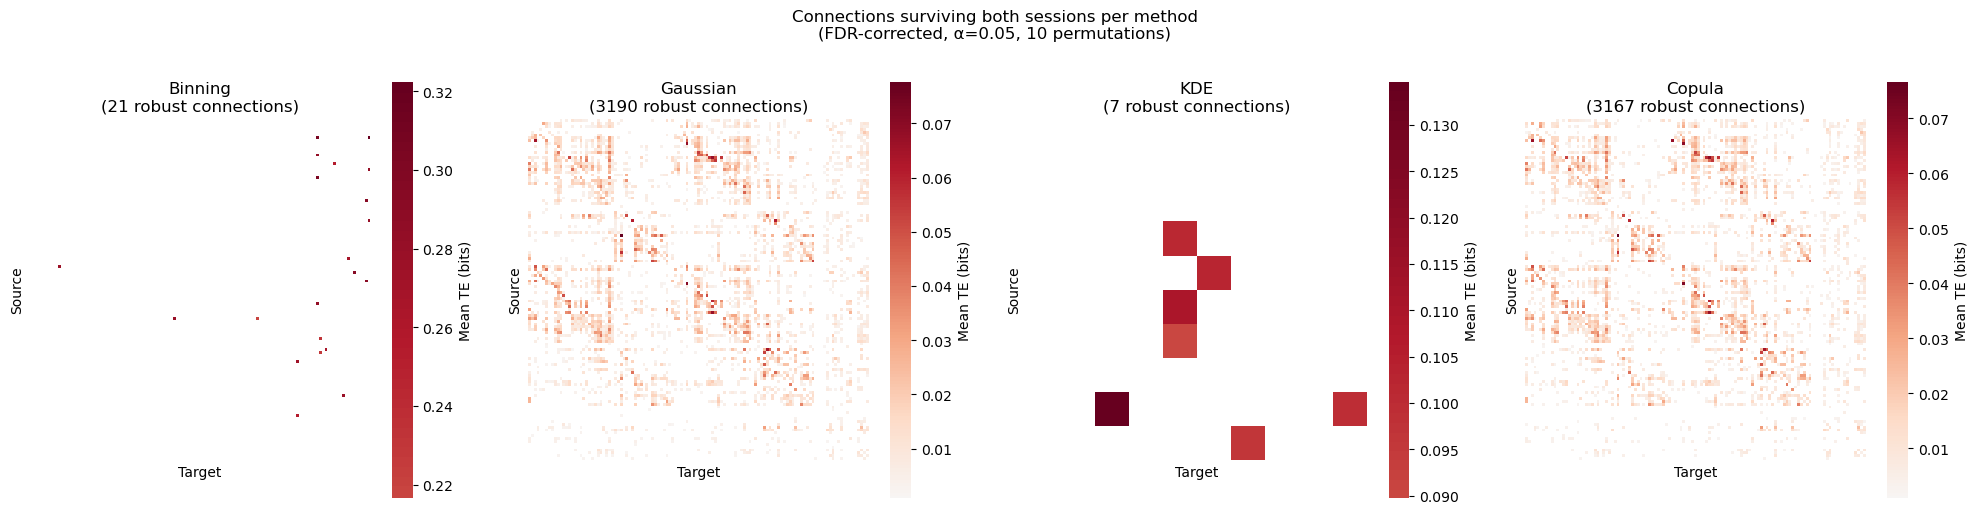

'\nfor sig1, sig2, te1, te2, name in methods_grid:\n    robust = sig1 & sig2\n    np.fill_diagonal(robust, False)\n    rows, cols = np.where(robust)\n\n    print(f"\n{\'=\'*50}")\n    print(f"{name} — {robust.sum()} connections surviving both sessions:")\n    print(f"{\'Source\':>8} {\'Target\':>8} | {\'TE S1\':>10} {\'TE S2\':>10} {\'Mean TE\':>10}")\n    print("-" * 50)\n    for i, j in zip(rows, cols):\n        mean_te = (te1[i,j] + te2[i,j]) / 2\n        print(f"{i:>8} {j:>8} | {te1[i,j]:>10.4f} {te2[i,j]:>10.4f} {mean_te:>10.4f}")\n'

In [ ]:
# --------------------------------------------------
# Robust mask: significant in BOTH sessions
# for Gaussian and Copula (our most reliable methods)
# --------------------------------------------------
robust_mask = sig_gauss_1 & sig_gauss_2 & sig_copula_1 & sig_copula_2
np.fill_diagonal(robust_mask, False)

print(f"Significant connections (FDR α={alpha}, {n_perms} permutations):")
print(f"  Gaussian  — S1: {sig_gauss_1.sum():4d},  S2: {sig_gauss_2.sum():4d}")
print(f"  Copula    — S1: {sig_copula_1.sum():4d},  S2: {sig_copula_2.sum():4d}")
print(f"  Binning   — S1: {sig_bin_1.sum():4d},  S2: {sig_bin_2.sum():4d}")
print(f"  KDE       — S1: {sig_kde_1.sum():4d},  S2: {sig_kde_2.sum():4d}")
print(f"  Robust (Gauss + Copula, both sessions): {robust_mask.sum()}")

# --------------------------------------------------
# Significant connections per method, per session
# 2 rows (sessions) x 4 columns (methods)
# --------------------------------------------------
sig_grid = [
    # Session 1
    (sig_bin_1,    "Binning — S1"),
    (sig_gauss_1,  "Gaussian — S1"),
    (sig_kde_1,    "KDE — S1"),
    (sig_copula_1, "Copula — S1"),
    # Session 2
    (sig_bin_2,    "Binning — S2"),
    (sig_gauss_2,  "Gaussian — S2"),
    (sig_kde_2,    "KDE — S2"),
    (sig_copula_2, "Copula — S2"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (mat, title) in zip(axes.flat, sig_grid):
    sns.heatmap(mat.astype(int), ax=ax, cmap="Blues", vmin=0, vmax=1,
                square=True, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{title}\n({mat.sum()} connections)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Significant connections per method and session\n"
             f"(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# TEs per method, per session
# 2 rows (sessions) x 4 columns (methods)
# --------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

sig_grid = [
    # Session 1
    (sig_bin_1,    TE_real_bin_1,    "Binning — S1"),
    (sig_gauss_1,  TE_real_gauss_1,  "Gaussian — S1"),
    (sig_kde_1,    TE_real_kde_1,    "KDE — S1"),
    (sig_copula_1, TE_real_copula_1, "Copula — S1"),
    # Session 2
    (sig_bin_2,    TE_real_bin_2,    "Binning — S2"),
    (sig_gauss_2,  TE_real_gauss_2,  "Gaussian — S2"),
    (sig_kde_2,    TE_real_kde_2,    "KDE — S2"),
    (sig_copula_2, TE_real_copula_2, "Copula — S2"),
]

for ax, (sig, te, title) in zip(axes.flat, sig_grid):
    # Keep real TE values only where significant, NaN elsewhere
    te_masked = np.where(sig, te, np.nan)
    sns.heatmap(te_masked, ax=ax, cmap="RdBu_r",
                center=0, square=True,
                cbar_kws={"label": "TE (bits)"},
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{title}\n({sig.sum()} significant)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Significant TE per method and session\n"
             f"(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Robust TEs across sessions (averaged between sessions)
# 4 columns (methods)
# --------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

methods_grid = [
    (sig_bin_1,    sig_bin_2,    TE_real_bin_1,    TE_real_bin_2,    "Binning"),
    (sig_gauss_1,  sig_gauss_2,  TE_real_gauss_1,  TE_real_gauss_2,  "Gaussian"),
    (sig_kde_1,    sig_kde_2,    TE_real_kde_1,    TE_real_kde_2,    "KDE"),
    (sig_copula_1, sig_copula_2, TE_real_copula_1, TE_real_copula_2, "Copula"),
]

# --- Summary ---
print(f"Robust connections surviving both sessions (FDR α={alpha}, {n_perms} permutations):")
print(f"{'Method':<12} {'S1':>6} {'S2':>6} {'Both':>6}")
print("-" * 32)
for sig1, sig2, te1, te2, name in methods_grid:
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    print(f"{name:<12} {sig1.sum():>6} {sig2.sum():>6} {robust.sum():>6}")

# --- Heatmaps ---
for ax, (sig1, sig2, te1, te2, name) in zip(axes, methods_grid):
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    avg_te = np.where(robust, (te1 + te2) / 2, np.nan)

    sns.heatmap(avg_te, ax=ax, cmap="RdBu_r", center=0, square=True,
                cbar_kws={"label": "Mean TE (bits)"},
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{name}\n({robust.sum()} robust connections)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Connections surviving both sessions per method\n"
             f"(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --- Detailed pair list (comment out if not needed) ---
"""
for sig1, sig2, te1, te2, name in methods_grid:
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    rows, cols = np.where(robust)

    print(f"\n{'='*50}")
    print(f"{name} — {robust.sum()} connections surviving both sessions:")
    print(f"{'Source':>8} {'Target':>8} | {'TE S1':>10} {'TE S2':>10} {'Mean TE':>10}")
    print("-" * 50)
    for i, j in zip(rows, cols):
        mean_te = (te1[i,j] + te2[i,j]) / 2
        print(f"{i:>8} {j:>8} | {te1[i,j]:>10.4f} {te2[i,j]:>10.4f} {mean_te:>10.4f}")
"""

# **CONSENSUS MATRIX**

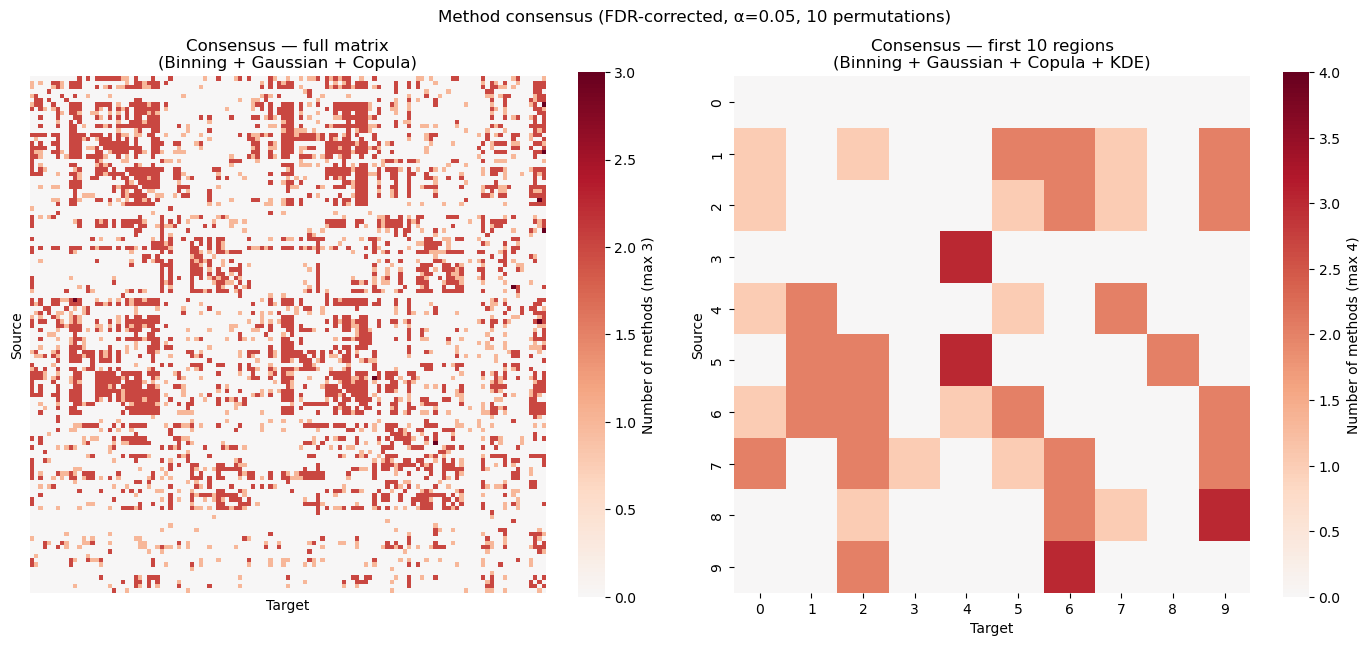

Full matrix (3 methods, 119 regions):
  0 methods agree: 10362 links
  1 methods agree: 1229 links
  2 methods agree: 2561 links
  3 methods agree:    9 links

10-region submatrix (4 methods):
  0 methods agree:   62 links
  1 methods agree:   14 links
  2 methods agree:   20 links
  3 methods agree:    4 links
  4 methods agree:    0 links


In [ ]:
# --------------------------------------------------
# Consensus matrix: two versions
# Left:  full 119x119, Gauss + Copula + Binning (3 methods)
# Right: 10x10 submatrix, all 4 methods including KDE
# --------------------------------------------------

# --- Left: 119x119, 3 methods ---
robust_bin    = sig_bin_1    & sig_bin_2;    np.fill_diagonal(robust_bin,    False)
robust_gauss  = sig_gauss_1  & sig_gauss_2;  np.fill_diagonal(robust_gauss,  False)
robust_copula = sig_copula_1 & sig_copula_2; np.fill_diagonal(robust_copula, False)
robust_kde    = sig_kde_1    & sig_kde_2;    np.fill_diagonal(robust_kde,    False)

consensus_full = (robust_bin.astype(int) +
                  robust_gauss.astype(int) +
                  robust_copula.astype(int))

# --- Right: 10x10, 4 methods ---
n = kde_regions
consensus_10 = (robust_bin[:n, :n].astype(int) +
                robust_gauss[:n, :n].astype(int) +
                robust_copula[:n, :n].astype(int) +
                robust_kde.astype(int))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(consensus_full, ax=axes[0], cmap="RdBu_r", center=0,  vmin=0, vmax=3,
            square=True, cbar_kws={"label": "Number of methods (max 3)"},
            xticklabels=False, yticklabels=False)
axes[0].set_title("Consensus — full matrix\n(Binning + Gaussian + Copula)")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Source")

sns.heatmap(consensus_10, ax=axes[1], cmap="RdBu_r", center=0, vmin=0, vmax=4,
            square=True, cbar_kws={"label": "Number of methods (max 4)"},
            xticklabels=range(n), yticklabels=range(n))
axes[1].set_title("Consensus — first 10 regions\n(Binning + Gaussian + Copula + KDE)")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Source")

plt.suptitle(f"Method consensus (FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
print("Full matrix (3 methods, 119 regions):")
for n_agree in range(4):
    print(f"  {n_agree} methods agree: {np.sum(consensus_full == n_agree):4d} links")

print(f"\n10-region submatrix (4 methods):")
for n_agree in range(5):
    print(f"  {n_agree} methods agree: {np.sum(consensus_10 == n_agree):4d} links")

# **LAG SWEEP**

In [ ]:
# LAG SWEEP — only robust average-TE heatmaps per method
lags_to_test = [1, 2, 5, 10, 20]

for lag in lags_to_test:
    print(f"\n{'='*60}")
    print(f"LAG = {lag}")
    print(f"{'='*60}")

    # --------------------------------------------------
    # Recompute real TE matrices for this lag
    # --------------------------------------------------
    TE_real_gauss_1  = nlib.transfer_entropy_matrix(data1_mat,                   method="gaussian", lag=lag)
    TE_real_gauss_2  = nlib.transfer_entropy_matrix(data2_mat,                   method="gaussian", lag=lag)

    TE_real_copula_1 = nlib.transfer_entropy_matrix(data1_mat,                   method="copula",   lag=lag)
    TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat,                   method="copula",   lag=lag)

    TE_real_bin_1    = nlib.transfer_entropy_matrix(data1_mat,                   method="binning",  lag=lag, n_bins=nbins)
    TE_real_bin_2    = nlib.transfer_entropy_matrix(data2_mat,                   method="binning",  lag=lag, n_bins=nbins)

    TE_real_kde_1    = nlib.transfer_entropy_matrix(data1_mat[:kde_regions, :],  method="kde",      lag=lag)
    TE_real_kde_2    = nlib.transfer_entropy_matrix(data2_mat[:kde_regions, :],  method="kde",      lag=lag)

    # --------------------------------------------------
    # Permutation tests
    # --------------------------------------------------
    sig_gauss_1,  _, _ = permutation_test_TE(
        data1_mat, TE_real_gauss_1,
        method="gaussian", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )
    sig_gauss_2,  _, _ = permutation_test_TE(
        data2_mat, TE_real_gauss_2,
        method="gaussian", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )

    sig_copula_1, _, _ = permutation_test_TE(
        data1_mat, TE_real_copula_1,
        method="copula", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )
    sig_copula_2, _, _ = permutation_test_TE(
        data2_mat, TE_real_copula_2,
        method="copula", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )

    sig_bin_1, _, _ = permutation_test_TE(
        data1_mat, TE_real_bin_1,
        method="binning", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag, n_bins=nbins
    )
    sig_bin_2, _, _ = permutation_test_TE(
        data2_mat, TE_real_bin_2,
        method="binning", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag, n_bins=nbins
    )

    sig_kde_1, _, _ = permutation_test_TE(
        data1_mat[:kde_regions, :], TE_real_kde_1,
        method="kde", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )
    sig_kde_2, _, _ = permutation_test_TE(
        data2_mat[:kde_regions, :], TE_real_kde_2,
        method="kde", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )

    # --------------------------------------------------
    # Methods list
    # --------------------------------------------------
    methods_grid = [
        (sig_bin_1,    sig_bin_2,    TE_real_bin_1,    TE_real_bin_2,    "Binning"),
        (sig_gauss_1,  sig_gauss_2,  TE_real_gauss_1,  TE_real_gauss_2,  "Gaussian"),
        (sig_kde_1,    sig_kde_2,    TE_real_kde_1,    TE_real_kde_2,    "KDE"),
        (sig_copula_1, sig_copula_2, TE_real_copula_1, TE_real_copula_2, "Copula"),
    ]

    # --------------------------------------------------
    # Plot only robust average TE heatmaps
    # --------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for ax, (sig1, sig2, te1, te2, name) in zip(axes, methods_grid):
        robust = sig1 & sig2
        np.fill_diagonal(robust, False)

        avg_te = np.where(robust, (te1 + te2) / 2, np.nan)

        sns.heatmap(
            avg_te,
            ax=ax,
            cmap="RdBu_r",
            center=0,
            square=True,
            cbar_kws={"label": "Mean TE (bits)"},
            xticklabels=False,
            yticklabels=False
        )

        ax.set_title(f"{name}\n({robust.sum()} robust links)")
        ax.set_xlabel("Target")
        ax.set_ylabel("Source")

    plt.suptitle(
        f"Average TE across datasets, masked by significance in both sessions — lag={lag}\n"
        f"(FDR-corrected, α={alpha}, {n_perms} permutations)",
        y=1.03
    )
    plt.tight_layout()
    plt.show()


LAG = 1


NameError: name 'nlib' is not defined